In [ ]:
import random
import torch

torch.manual_seed(11231)
np.random.seed(11231)
random.seed(11231)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(11231)

Trening se izvršava na: cuda
Epoha 1/30 | Loss: -2.2381
Epoha 2/30 | Loss: -2.8372
Epoha 3/30 | Loss: -2.8641
Epoha 4/30 | Loss: -2.8920
Epoha 5/30 | Loss: -2.9094
Epoha 6/30 | Loss: -2.9272
Epoha 7/30 | Loss: -2.9432
Epoha 8/30 | Loss: -2.9513
Epoha 9/30 | Loss: -2.9588
Epoha 10/30 | Loss: -2.9628
Epoha 11/30 | Loss: -2.9672
Epoha 12/30 | Loss: -2.9751
Epoha 13/30 | Loss: -2.9794
Epoha 14/30 | Loss: -2.9867
Epoha 15/30 | Loss: -2.9932
Epoha 16/30 | Loss: -2.9955
Epoha 17/30 | Loss: -3.0015
Epoha 18/30 | Loss: -3.0095
Epoha 19/30 | Loss: -3.0163
Epoha 20/30 | Loss: -3.0220
Epoha 21/30 | Loss: -3.0316
Epoha 22/30 | Loss: -3.0383
Epoha 23/30 | Loss: -3.0490
Epoha 24/30 | Loss: -3.0548
Epoha 25/30 | Loss: -3.0653
Epoha 26/30 | Loss: -3.0741
Epoha 27/30 | Loss: -3.0828
Epoha 28/30 | Loss: -3.0904
Epoha 29/30 | Loss: -3.1013
Epoha 30/30 | Loss: -3.1088


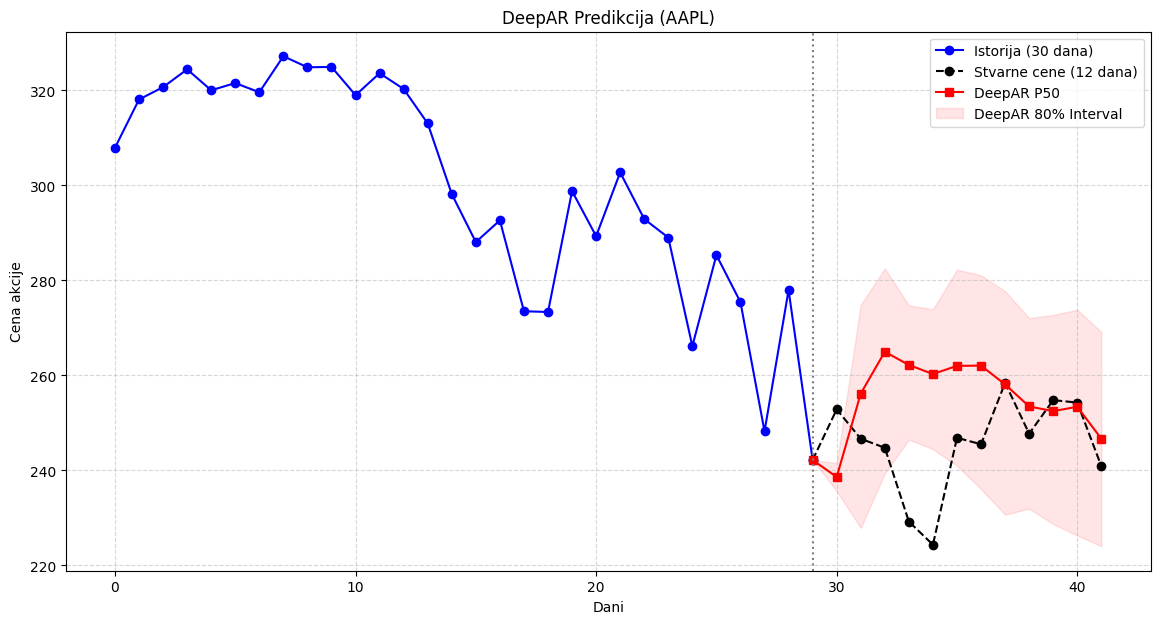

In [ ]:

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DeepAR(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super(DeepAR, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear_mu = nn.Linear(hidden_size, 1)
        self.linear_sigma = nn.Linear(hidden_size, 1)
        self.softplus = nn.Softplus()

    def forward(self, x, hidden=None):
        if hidden is None:
            h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
            c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
            hidden = (h_0, c_0)
        lstm_out, hidden = self.lstm(x, hidden)
        mu = self.linear_mu(lstm_out)
        sigma = self.softplus(self.linear_sigma(lstm_out)) + 1e-4
        return mu, sigma, hidden

class GlobalStockDataset(Dataset):
    def __init__(self, df_pivot, seq_len=30, pred_len=12):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_size = seq_len + pred_len
        self.data_matrix = torch.tensor(df_pivot.values, dtype=torch.float32)
        self.num_tickers = df_pivot.shape[1]
        self.num_windows = len(df_pivot) - self.window_size + 1
        day_of_week = df_pivot.index.dayofweek.values / 6.0
        month_of_year = (df_pivot.index.month.values - 1) / 11.0
        self.day_of_week = torch.tensor(day_of_week, dtype=torch.float32)
        self.month_of_year = torch.tensor(month_of_year, dtype=torch.float32)

    def __len__(self):
        return self.num_windows * self.num_tickers

    def __getitem__(self, idx):
        window_idx = idx // self.num_tickers
        ticker_idx = idx % self.num_tickers
        window = self.data_matrix[window_idx : window_idx + self.window_size, ticker_idx]
        v = 1.0 + torch.mean(window[:self.seq_len])
        window_scaled = window / v
        age = torch.arange(self.window_size, dtype=torch.float32) / self.window_size
        dow_window = self.day_of_week[window_idx : window_idx + self.window_size]
        moy_window = self.month_of_year[window_idx : window_idx + self.window_size]
        x_target = window_scaled[:-1].unsqueeze(-1)
        x_age = age[:-1].unsqueeze(-1)
        x_dow = dow_window[:-1].unsqueeze(-1)
        x_moy = moy_window[:-1].unsqueeze(-1)
        x = torch.cat([x_target, x_age, x_dow, x_moy], dim=-1)
        y = window_scaled[1:]
        return x, y, v

def loss_fn(mu, sigma, target):
    dist = torch.distributions.LogNormal(mu, sigma)
    return -torch.mean(dist.log_prob(target + 1e-5))

def train_model(df_pivot, epochs=30, batch_size=32, lr=1e-3, seq_len=30, pred_len=12):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Trening se izvršava na: {device}")
    dataset = GlobalStockDataset(df_pivot, seq_len=seq_len, pred_len=pred_len)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = DeepAR(input_size=4, hidden_size=64, num_layers=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y, v in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            mu, sigma, _ = model(x)
            loss = loss_fn(mu.squeeze(-1), sigma.squeeze(-1), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
        print(f"Epoha {epoch+1}/{epochs} | Loss: {epoch_loss / len(dataset):.4f}")
    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model

def predict(model, df_cutoff, target_ticker, seq_len=30, pred_len=12, num_samples=100):
    model.eval()
    model.to("cpu")
    window_dates = df_cutoff.index[-(seq_len + pred_len):]
    dow_all = torch.tensor(window_dates.dayofweek.values / 6.0, dtype=torch.float32)
    moy_all = torch.tensor((window_dates.month.values - 1) / 11.0, dtype=torch.float32)
    history = df_cutoff[target_ticker].values[-(seq_len + pred_len):-pred_len]
    history_tensor = torch.tensor(history, dtype=torch.float32)
    v = 1.0 + torch.mean(history_tensor)
    history_scaled = history_tensor / v
    samples = torch.zeros(num_samples, pred_len)
    window_size = seq_len + pred_len
    with torch.no_grad():
        for i in range(num_samples):
            hidden = None
            age_seq = torch.arange(seq_len, dtype=torch.float32) / window_size
            x_init = torch.stack([history_scaled, age_seq, dow_all[:seq_len], moy_all[:seq_len]], dim=-1).unsqueeze(0)
            mu, sigma, hidden = model(x_init)
            curr_mu = mu[:, -1, :]
            curr_sigma = sigma[:, -1, :]
            for t in range(pred_len):
                dist = torch.distributions.LogNormal(curr_mu, curr_sigma)
                sample_scaled = dist.sample()
                samples[i, t] = sample_scaled.item() * v
                next_age = torch.tensor([[[ (seq_len + t) / window_size ]]], dtype=torch.float32)
                next_dow = dow_all[seq_len + t].reshape(1, 1, 1)
                next_moy = moy_all[seq_len + t].reshape(1, 1, 1)
                next_x = torch.cat([sample_scaled.unsqueeze(1), next_age, next_dow, next_moy], dim=-1)
                curr_mu, curr_sigma, hidden = model(next_x, hidden)
                curr_mu = curr_mu.squeeze(0)
                curr_sigma = curr_sigma.squeeze(0)
    return samples

if __name__ == "__main__":
    df = pd.read_csv("baze_stocks_ts.csv")
    df_pivot = df.pivot(index="Date", columns="Ticker", values="Adj Close")
    df_pivot.index = pd.to_datetime(df_pivot.index)
    df_pivot = df_pivot.sort_index().ffill().bfill()

    df_cutoff = df_pivot.loc[:"2020-04-01"]
    train_pivot = df_cutoff.iloc[:-42]

    seq_len = 30
    pred_len = 12

    model = train_model(train_pivot, epochs=30, batch_size=32, seq_len=seq_len, pred_len=pred_len)

    target_ticker = df_cutoff.columns[0]
    test_history = df_cutoff[target_ticker].values[-42:-12]
    stvarna_buducnost = df_cutoff[target_ticker].values[-12:]

    predictions = predict(model, df_cutoff, target_ticker, seq_len=seq_len, pred_len=pred_len, num_samples=100)

    p50 = torch.median(predictions, dim=0).values.numpy()
    p10 = torch.quantile(predictions, 0.1, dim=0).numpy()
    p90 = torch.quantile(predictions, 0.9, dim=0).numpy()

    plt.figure(figsize=(14, 7))
    x_istorija = np.arange(seq_len)
    x_predikcija = np.arange(seq_len, seq_len + pred_len)
    x_spojeno = np.concatenate(([x_istorija[-1]], x_predikcija))

    plt.plot(x_istorija, test_history, label="Istorija (30 dana)", color="blue", marker="o")

    y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
    plt.plot(x_spojeno, y_stvarna, label="Stvarne cene (12 dana)", color="black", linestyle="--", marker="o")

    y_p50 = np.concatenate(([test_history[-1]], p50))
    plt.plot(x_spojeno, y_p50, label="DeepAR P50", color="red", marker="s")

    y_p10 = np.concatenate(([test_history[-1]], p10))
    y_p90 = np.concatenate(([test_history[-1]], p90))
    plt.fill_between(x_spojeno, y_p10, y_p90, color="red", alpha=0.1, label="DeepAR 80% Interval")

    plt.axvline(x=seq_len-1, color="gray", linestyle=":")
    plt.title(f"DeepAR Predikcija ({target_ticker})")
    plt.xlabel("Dani")
    plt.ylabel("Cena akcije")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

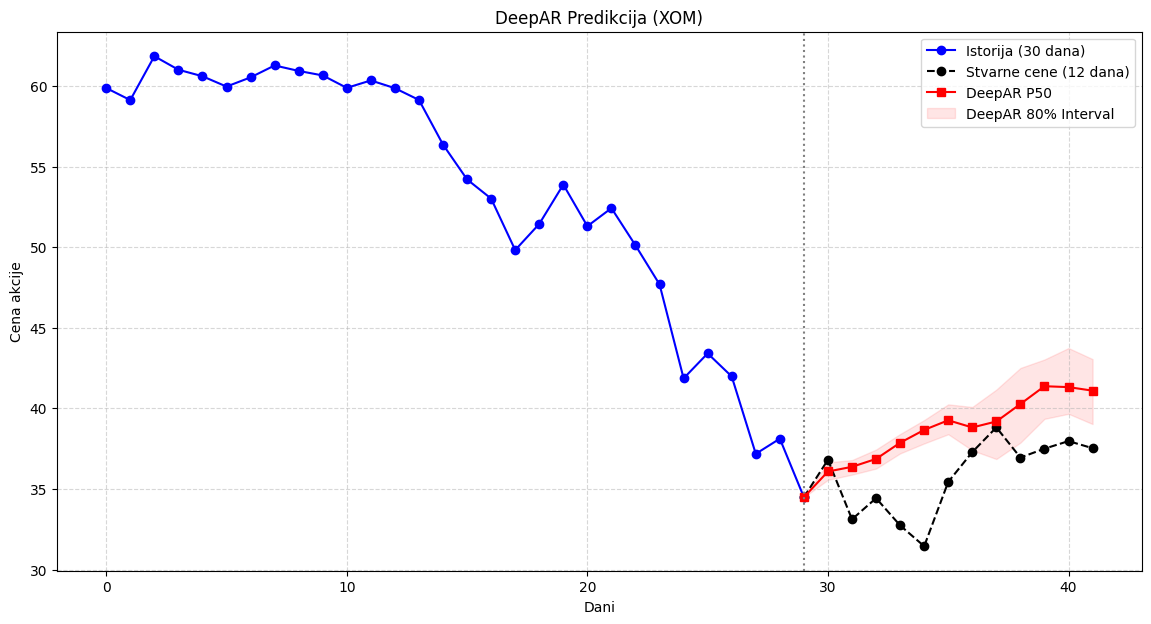

In [ ]:
target_ticker = df_cutoff.columns[29]
test_history = df_cutoff[target_ticker].values[-42:-12]
stvarna_buducnost = df_cutoff[target_ticker].values[-12:]

predictions = predict(model, df_cutoff, target_ticker, seq_len=seq_len, pred_len=pred_len, num_samples=100)

p50 = torch.median(predictions, dim=0).values.numpy()
p10 = torch.quantile(predictions, 0.1, dim=0).numpy()
p90 = torch.quantile(predictions, 0.9, dim=0).numpy()

plt.figure(figsize=(14, 7))
x_istorija = np.arange(seq_len)
x_predikcija = np.arange(seq_len, seq_len + pred_len)
x_spojeno = np.concatenate(([x_istorija[-1]], x_predikcija))

plt.plot(x_istorija, test_history, label="Istorija (30 dana)", color="blue", marker="o")

y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
plt.plot(x_spojeno, y_stvarna, label="Stvarne cene (12 dana)", color="black", linestyle="--", marker="o")

y_p50 = np.concatenate(([test_history[-1]], p50))
plt.plot(x_spojeno, y_p50, label="DeepAR P50", color="red", marker="s")

y_p10 = np.concatenate(([test_history[-1]], p10))
y_p90 = np.concatenate(([test_history[-1]], p90))
plt.fill_between(x_spojeno, y_p10, y_p90, color="red", alpha=0.1, label="DeepAR 80% Interval")

plt.axvline(x=seq_len-1, color="gray", linestyle=":")
plt.title(f"DeepAR Predikcija ({target_ticker})")
plt.xlabel("Dani")
plt.ylabel("Cena akcije")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
import numpy as np
import torch

def izracunaj_metrike(stvarna_baza, predikcije):
    y = np.array(stvarna_baza)

    if isinstance(predikcije, torch.Tensor):
        p50 = torch.median(predikcije, dim=0).values.numpy()
        p10 = torch.quantile(predikcije, 0.1, dim=0).numpy()
        p90 = torch.quantile(predikcije, 0.9, dim=0).numpy()
    else:
        p50 = np.median(predikcije, axis=0)
        p10 = np.percentile(predikcije, 10, axis=0)
        p90 = np.percentile(predikcije, 90, axis=0)

    rmse = np.sqrt(np.mean((y - p50) ** 2))
    nd = np.sum(np.abs(y - p50)) / np.sum(np.abs(y))

    def pinball_loss(y_true, y_pred, rho):
        return np.maximum(rho * (y_true - y_pred), (rho - 1) * (y_true - y_pred))

    ql_10 = 2 * np.sum(pinball_loss(y, p10, 0.1)) / np.sum(np.abs(y))
    ql_90 = 2 * np.sum(pinball_loss(y, p90, 0.9)) / np.sum(np.abs(y))

    metrike = {
        "RMSE": rmse,
        "ND": nd,
        "QL_0.10": ql_10,
        "QL_0.90": ql_90
    }

    for k, v in metrike.items():
        print(f"{k}: {v:.4f}")

    return metrike

metrike = izracunaj_metrike(stvarna_buducnost, predictions)

RMSE: 17.4528
ND: 0.0542
QL_0.10: 0.0345
QL_0.90: 0.0301
